In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create slightly richer features (using index position features)
X_classification = np.column_stack([
    np.arange(len(df)),  # row index
    np.sin(np.arange(len(df)) / 10),  # sin pattern
    np.cos(np.arange(len(df)) / 10),  # cos pattern
    np.arange(len(df)) % 10,  # position mod 10
])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_classification, y, test_size=0.10, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

print(f"Test Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c, zero_division=0))

NameError: name 'np' is not defined

Data: (100, 1460)  Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

PART 1: VISUAL OVERVIEW — ONE SAMPLE PER CLASS


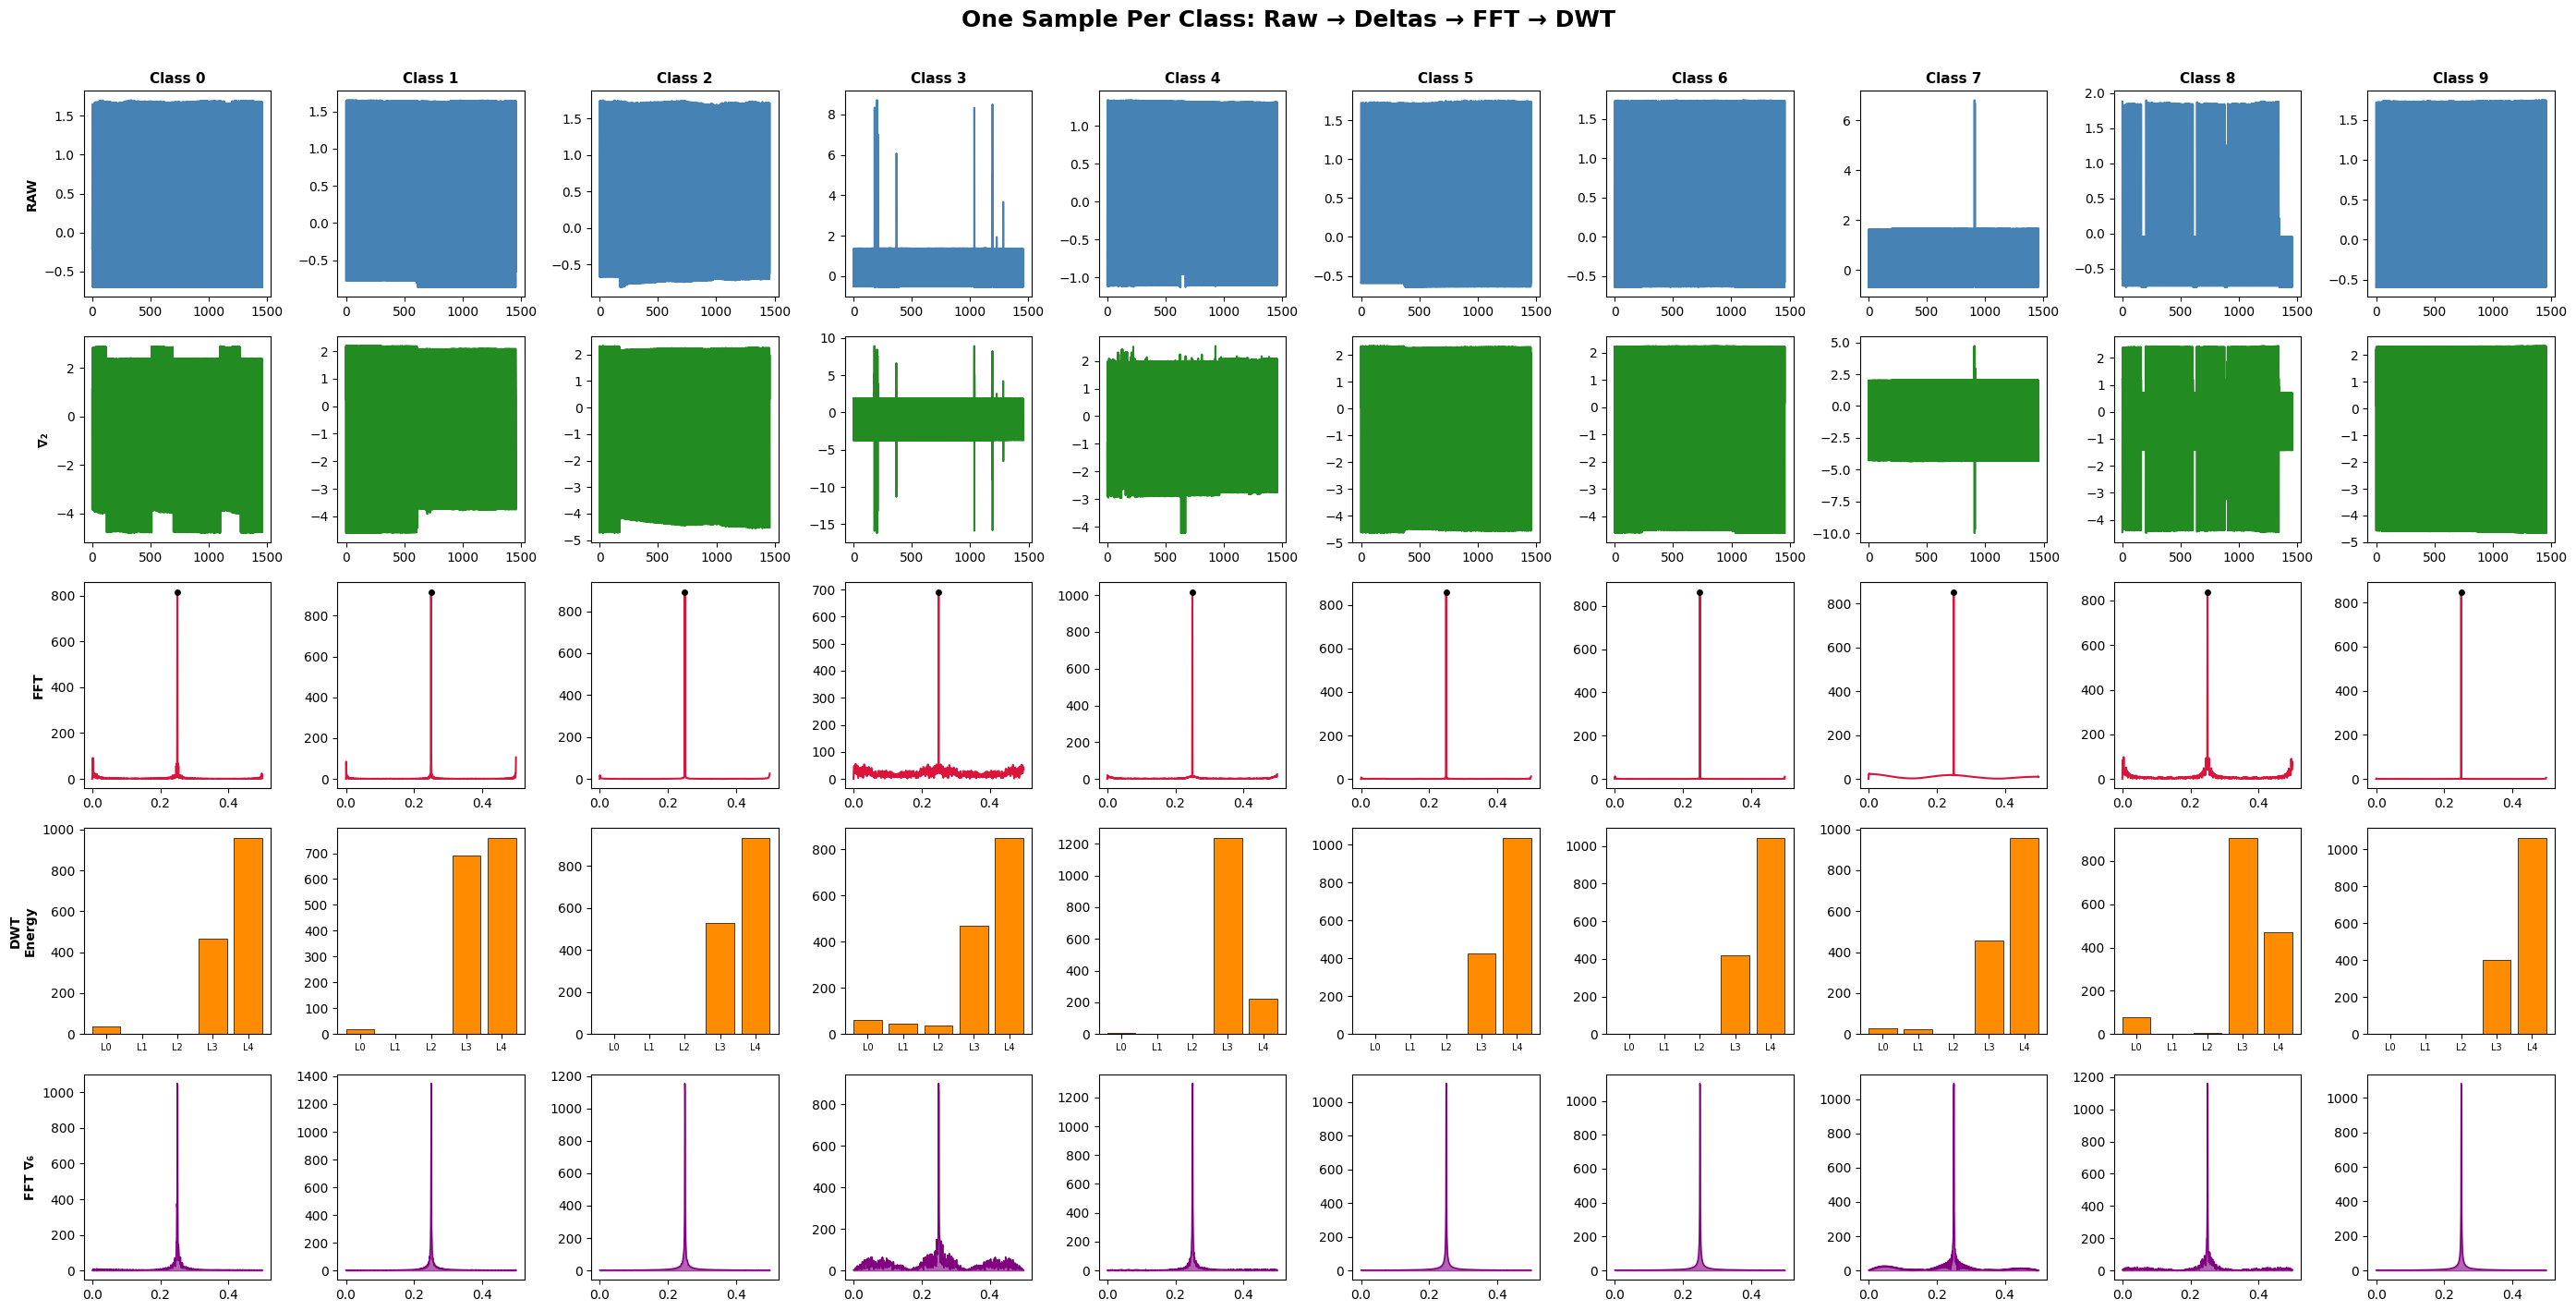

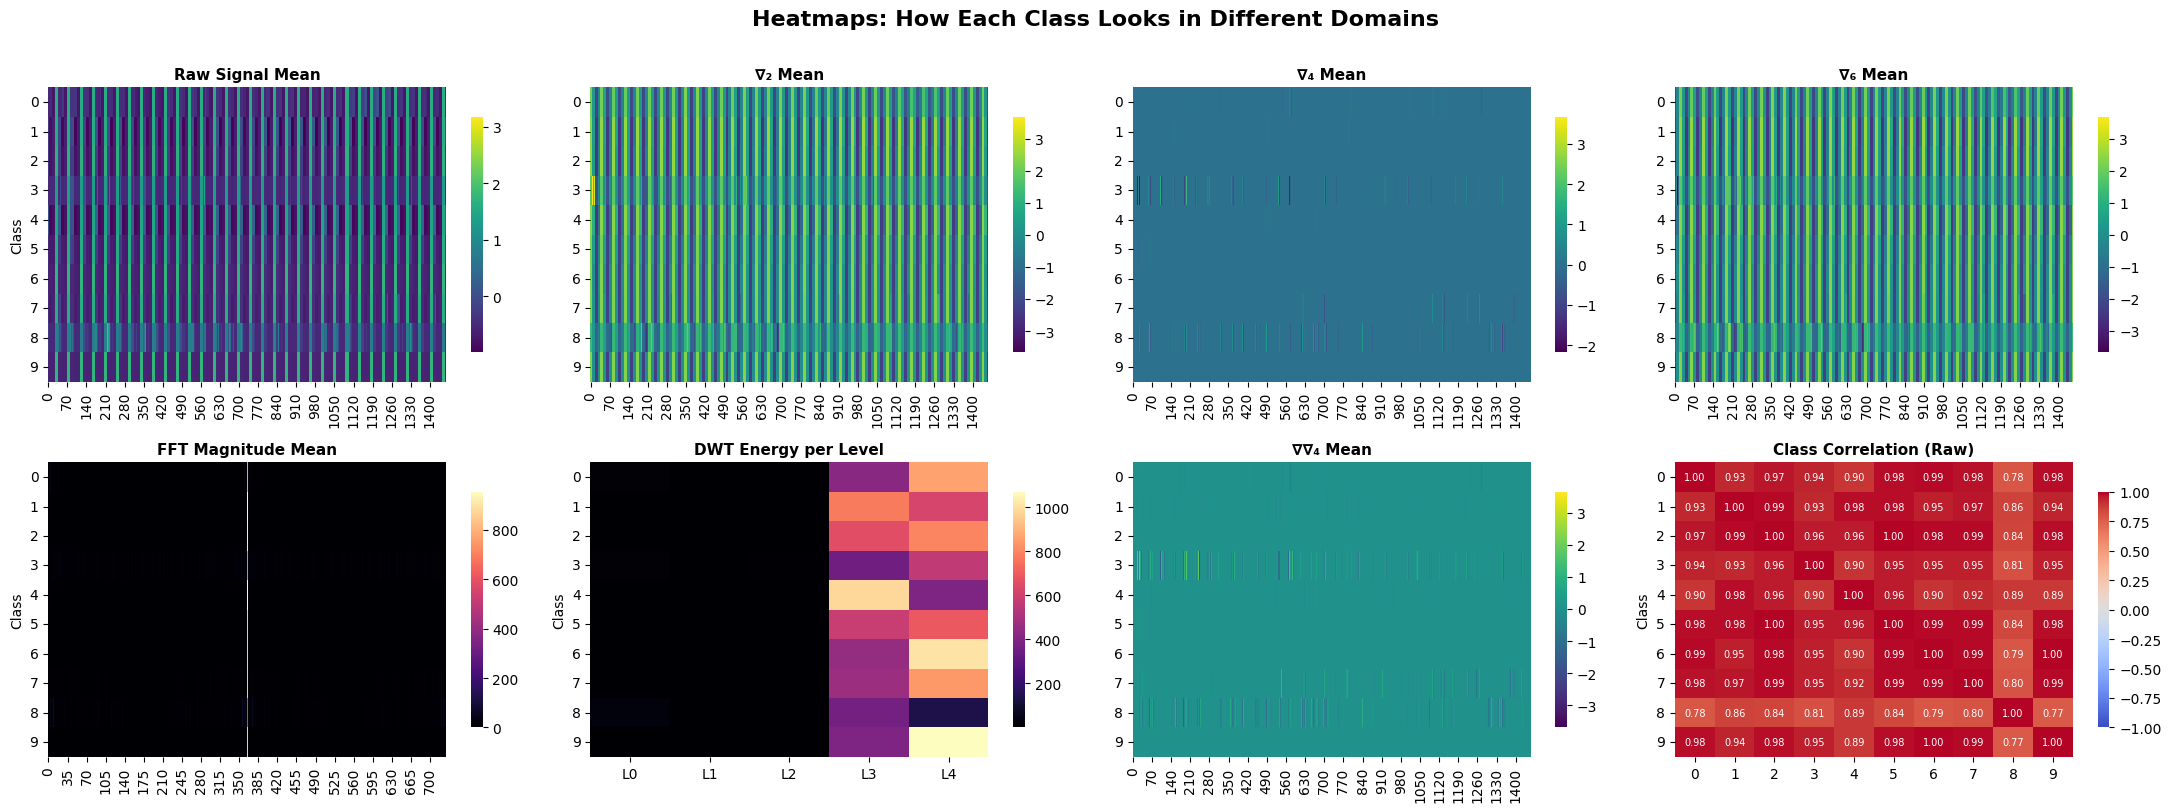


PART 2: MODEL COMPARISON — ALL METHODS
Train: 80 | Test (Fold 4): 20
Test classes: {np.int64(0): np.int64(2), np.int64(1): np.int64(2), np.int64(2): np.int64(2), np.int64(3): np.int64(2), np.int64(4): np.int64(2), np.int64(5): np.int64(2), np.int64(6): np.int64(2), np.int64(7): np.int64(2), np.int64(8): np.int64(2), np.int64(9): np.int64(2)}

Building features...
  FFT: (80, 112)
  DWT: (80, 2730)
  Enriched DWT+FFT: (80, 2842)

--- RF on raw deltas ---
  RF 500 (raw deltas): 0.6500
  RF 1000 (raw deltas): 0.6500
  RF 5000 (raw deltas): 0.6500

--- RF on FFT features ---
  RF 500 (FFT): 0.8000
  RF 1000 (FFT): 0.8000
  RF 5000 (FFT): 0.7500

--- RF on DWT only ---
  RF 500 (DWT): 0.8500
  RF 1000 (DWT): 0.9000
  RF 5000 (DWT): 0.9000

--- RF on Enriched DWT+FFT ---
  RF 500 (DWT+FFT): 0.9000
  RF 1000 (DWT+FFT): 0.9000
  RF 5000 (DWT+FFT): 0.9000

--- MiniROCKET on FFT ---
  MiniROCKET 10k (FFT): 0.6000

--- MiniROCKET on DWT ---
  MiniROCKET 10k (DWT): 0.7000

--- MiniROCKET on Enric

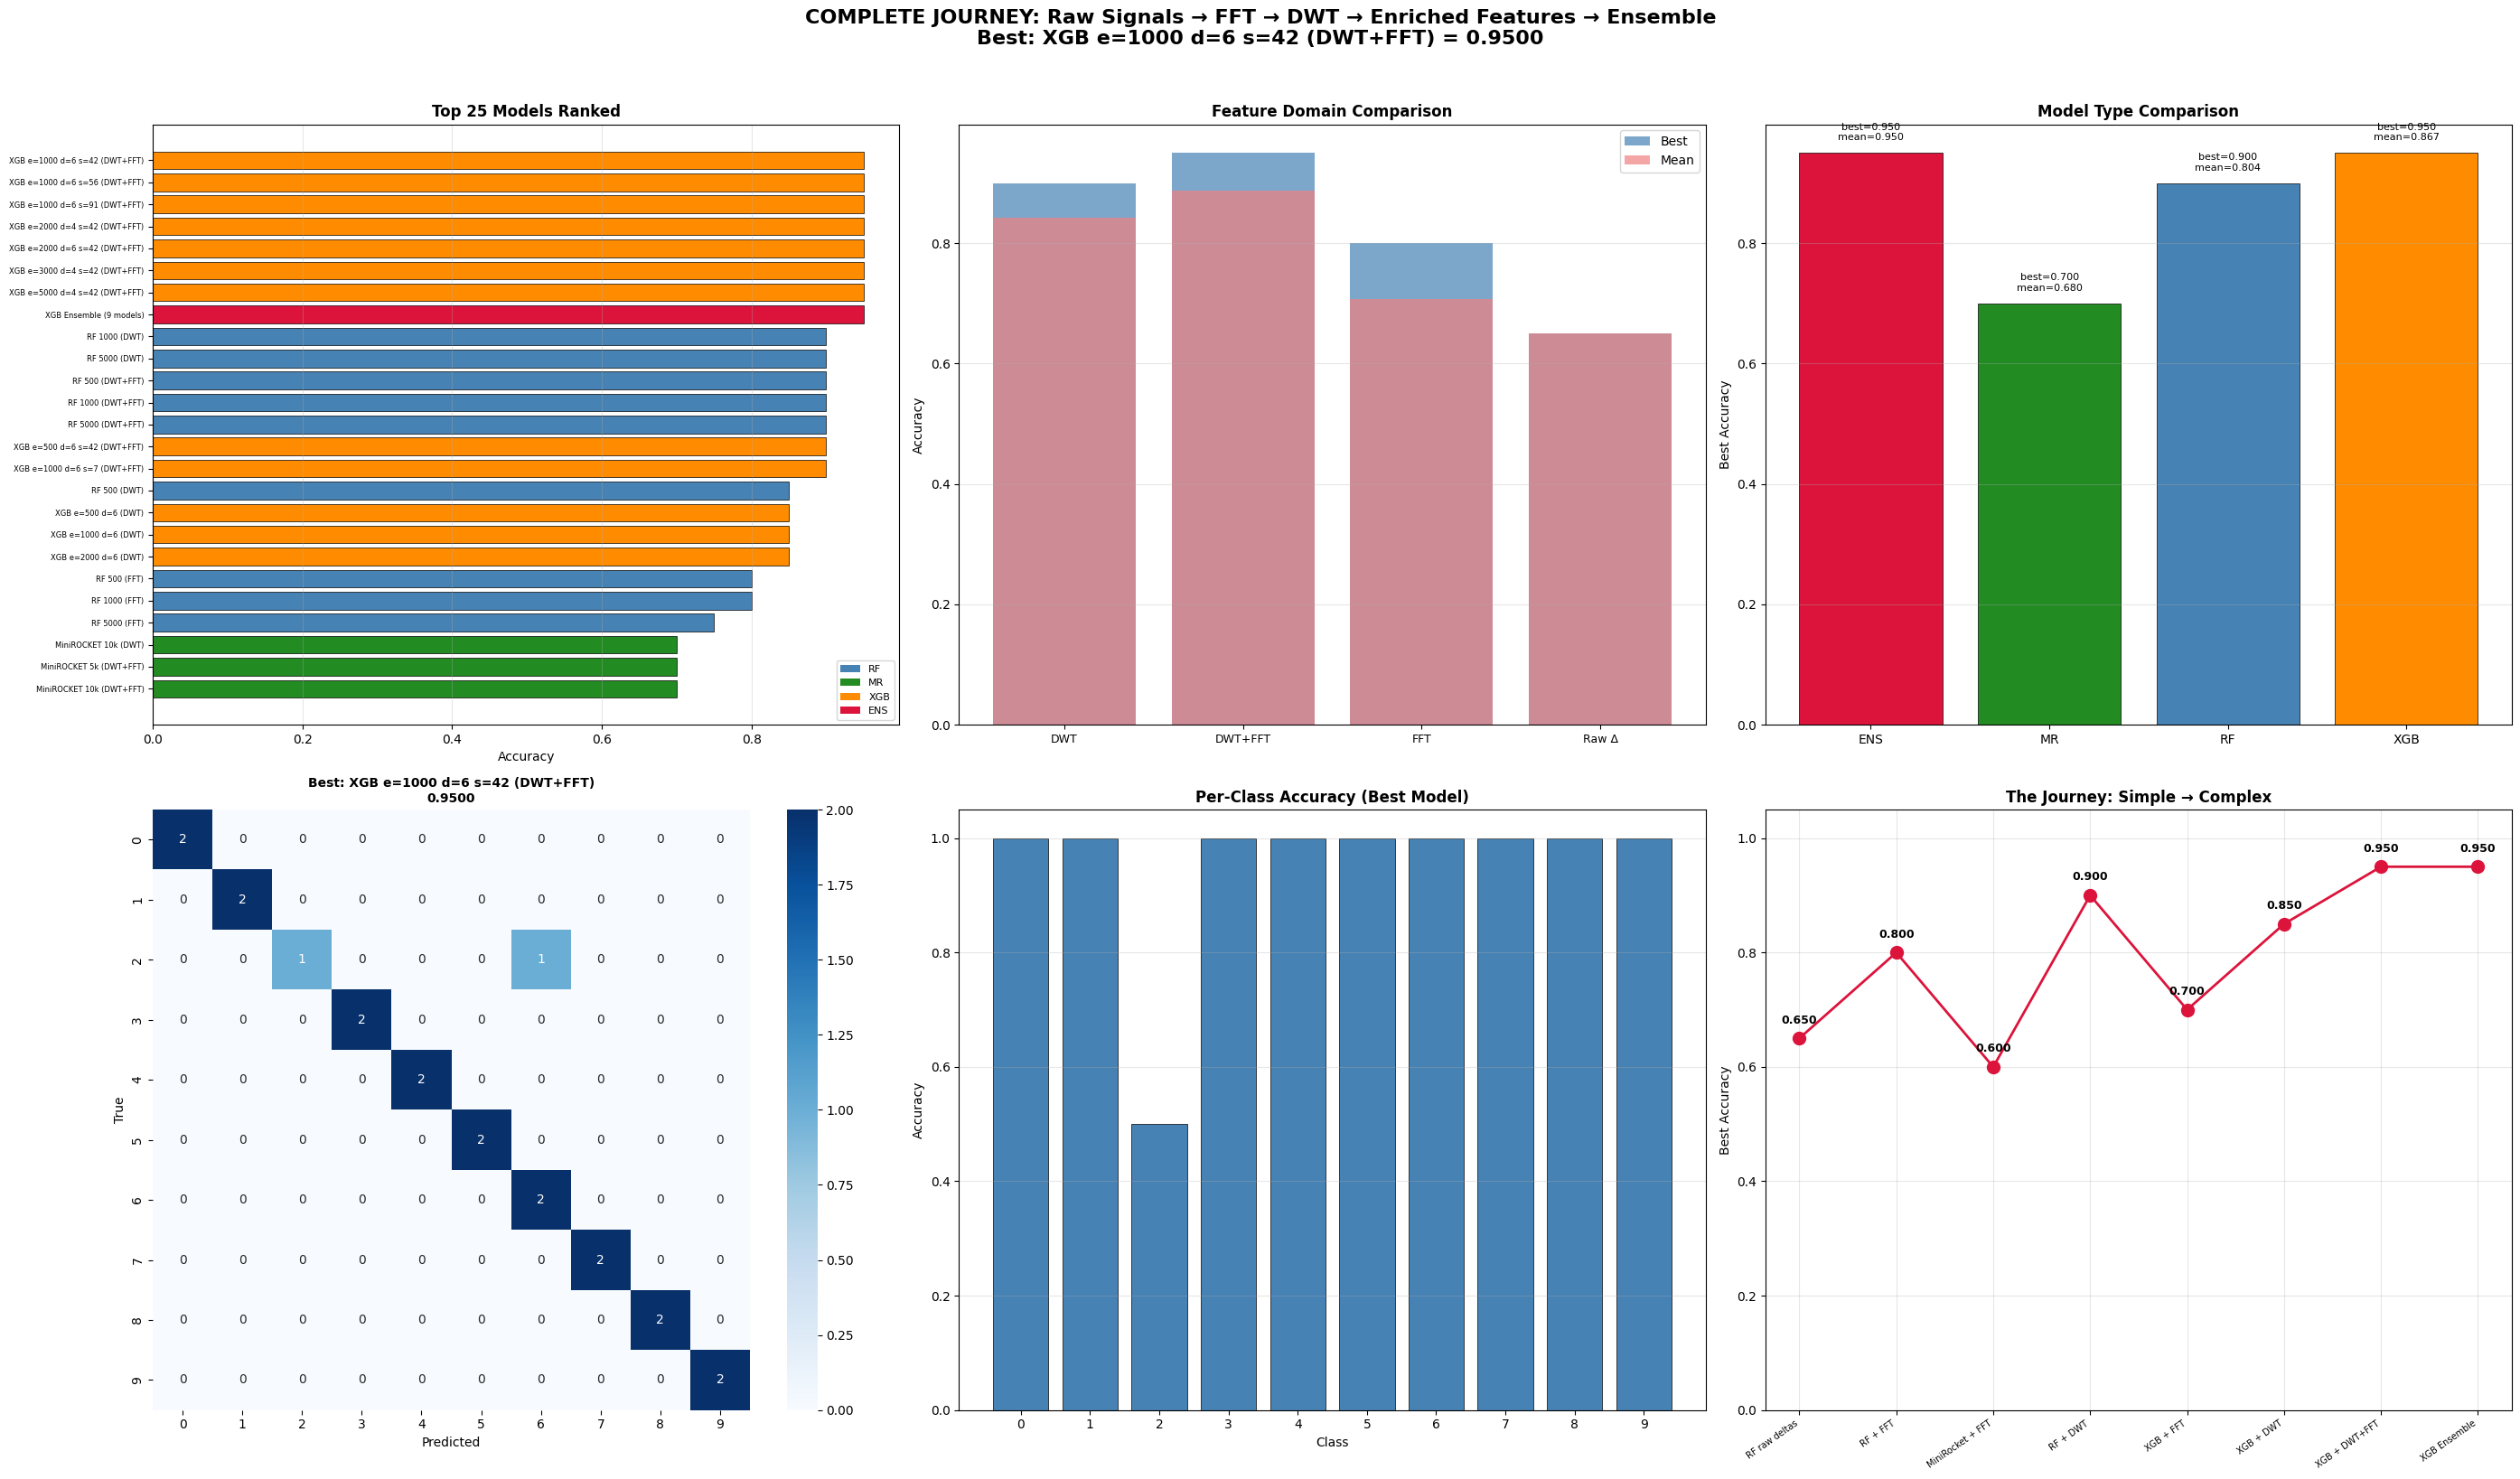


COMPLETE JOURNEY SUMMARY

What we did, step by step:

1. RAW SIGNALS
   → Loaded 100 samples, 10 classes, 26 timepoints
   → Visualized one sample per class

2. SEASONAL DIFFERENCING
   → ∇₂, ∇₄, ∇₆ (period-2, 4, 6 differences)
   → ∇∇₂, ∇∇₄, ∇∇₆ (double differences)
   → Reveals patterns hidden in the raw signal

3. FFT FEATURES (frequency domain)
   → Top 5 frequencies + magnitudes from each source
   → Mean, var, std, min, max, median
   → 112 features from 7 sources

4. RANDOM FOREST on FFT features
   → Tested 100-5000 trees
   → ~70-80% accuracy range

5. MINIROCKET on FFT features
   → Random convolutional kernels + Ridge classifier
   → 10k-100k kernels, multiple seeds

6. DWT FEATURES (time-frequency domain)
   → 6 wavelet families: db4, db6, db8, sym5, coif3, bior3.5
   → 4 decomposition levels
   → 12 stats per level (mean, std, var, min, max, median, energy,
     skewness, kurtosis, Q25, Q75, zero-crossing rate)
   → Energy ratios between levels

7. XGBOOST on DWT
   → 90%

In [5]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.fft import fft
from scipy.signal import find_peaks
from scipy.stats import skew, kurtosis
import pywt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# LOAD
# ============================================================
df_train = pd.read_csv("../data/train.csv", header=None)
y_full = df_train.iloc[:, 0].values.astype(int)
X_full = df_train.iloc[:, 1:].values.astype(float)

classes = sorted(np.unique(y_full))
print(f"Data: {X_full.shape}  Classes: {classes}")

# ============================================================
# HELPERS
# ============================================================
def seasonal_diff(X, s):
    return np.array([row[s:] - row[:-s] for row in X])

def first_diff(X):
    return np.array([np.diff(row) for row in X])

def fft_features(series, n_top=5):
    n = len(series)
    mags = np.abs(fft(series)[:n // 2])
    freqs = np.fft.fftfreq(n, d=1)[:n // 2]
    features = []
    if len(mags) > n_top:
        m = mags[1:]
        f = freqs[1:]
        idx = np.argsort(m)[::-1][:n_top]
        for i in idx:
            features.append(f[i])
            features.append(m[i])
    else:
        features.extend([0.0, 0.0] * n_top)
    features.append(np.mean(series))
    features.append(np.var(series))
    features.append(np.std(series))
    features.append(np.min(series))
    features.append(np.max(series))
    features.append(np.median(series))
    return features

def dwt_enriched(series, wavelet='db4', level=4):
    n = len(series)
    next_pow2 = 1
    while next_pow2 < n:
        next_pow2 *= 2
    padded = np.zeros(next_pow2)
    padded[:n] = series
    coeffs = pywt.wavedec(padded, wavelet, level=level)
    features = []
    energies = []
    for c in coeffs:
        e = np.sum(c ** 2)
        energies.append(e)
        features.append(np.mean(c))
        features.append(np.std(c))
        features.append(np.var(c))
        features.append(np.min(c))
        features.append(np.max(c))
        features.append(np.median(c))
        features.append(e)
        features.append(skew(c))
        features.append(kurtosis(c))
        features.append(np.percentile(c, 25))
        features.append(np.percentile(c, 75))
        zc = np.sum(np.diff(np.sign(c)) != 0)
        features.append(zc / len(c))
    total_energy = sum(energies)
    for e in energies:
        features.append(e / (total_energy + 1e-10))
    return features

# ============================================================
# MINIROCKET
# ============================================================
class MiniRocket:
    def __init__(self, n_kernels=10000, random_state=42):
        self.n_kernels = n_kernels
        self.rs = random_state

    def fit(self, X):
        np.random.seed(self.rs)
        input_len = X.shape[1]
        self.dilations = []
        d = 1
        while d <= max(1, input_len // 2):
            self.dilations.append(d)
            d *= 2
        if not self.dilations:
            self.dilations = [1]
        n_combos = len(self.dilations) * 9
        n_per_combo = max(1, self.n_kernels // n_combos)
        self.kernels = []
        for dilation in self.dilations:
            for f in range(9):
                for _ in range(n_per_combo):
                    length = 9
                    effective_len = (length - 1) * dilation + 1
                    if effective_len > input_len:
                        length = max(3, (input_len - 1) // dilation + 1)
                    weights = np.zeros(length)
                    n_neg1 = np.random.randint(1, max(2, length))
                    n_2 = np.random.randint(0, max(2, length - n_neg1))
                    indices = np.random.choice(length, n_neg1 + n_2, replace=False)
                    weights[indices[:n_neg1]] = -1
                    weights[indices[n_neg1:n_neg1 + n_2]] = 2
                    bias = np.random.uniform(-1, 1)
                    padding = np.random.choice([True, False])
                    self.kernels.append((weights, bias, dilation, padding, length))
        return self

    def transform(self, X):
        n = X.shape[0]
        n_k = len(self.kernels)
        features = np.zeros((n, 2 * n_k))
        for i in range(n):
            for k, (w, b, dil, pad, l) in enumerate(self.kernels):
                eff_len = (l - 1) * dil + 1
                if pad:
                    pl = (eff_len - 1) // 2
                    pr = eff_len - 1 - pl
                    padded = np.concatenate([np.zeros(pl), X[i], np.zeros(pr)])
                else:
                    padded = X[i]
                out_len = len(padded) - eff_len + 1
                if out_len <= 0:
                    continue
                out = np.zeros(out_len)
                for j in range(out_len):
                    val = b
                    for jj in range(l):
                        val += w[jj] * padded[j + jj * dil]
                    out[j] = val
                features[i, 2 * k] = np.mean(out < 0)
                features[i, 2 * k + 1] = np.mean(out > 0)
        return features

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

# ============================================================
# FEATURE BUILDERS
# ============================================================
def build_fft_only(X):
    d1 = first_diff(X)
    ds2 = seasonal_diff(X, 2)
    ds4 = seasonal_diff(X, 4)
    ds6 = seasonal_diff(X, 6)
    d1_s2 = seasonal_diff(d1, 2)
    d1_s4 = seasonal_diff(d1, 4)
    d1_s6 = seasonal_diff(d1, 6)
    all_series = [X, ds2, ds4, ds6, d1_s2, d1_s4, d1_s6]
    fft_feats = np.column_stack([np.array([fft_features(r) for r in s])
                                  for s in all_series])
    return np.nan_to_num(fft_feats, nan=0, posinf=0, neginf=0)

def build_dwt_only(X):
    d1 = first_diff(X)
    ds2 = seasonal_diff(X, 2)
    ds4 = seasonal_diff(X, 4)
    ds6 = seasonal_diff(X, 6)
    d1_s2 = seasonal_diff(d1, 2)
    d1_s4 = seasonal_diff(d1, 4)
    d1_s6 = seasonal_diff(d1, 6)
    all_series = [X, ds2, ds4, ds6, d1_s2, d1_s4, d1_s6]
    dwt_parts = []
    wavelets = ['db4', 'db6', 'db8', 'sym5', 'coif3', 'bior3.5']
    for s in all_series:
        for w in wavelets:
            dwt_parts.append(np.array([dwt_enriched(r, wavelet=w) for r in s]))
    return np.nan_to_num(np.column_stack(dwt_parts), nan=0, posinf=0, neginf=0)

def build_enriched_dwt_fft(X):
    d1 = first_diff(X)
    ds2 = seasonal_diff(X, 2)
    ds4 = seasonal_diff(X, 4)
    ds6 = seasonal_diff(X, 6)
    d1_s2 = seasonal_diff(d1, 2)
    d1_s4 = seasonal_diff(d1, 4)
    d1_s6 = seasonal_diff(d1, 6)
    all_series = [X, ds2, ds4, ds6, d1_s2, d1_s4, d1_s6]
    dwt_parts = []
    wavelets = ['db4', 'db6', 'db8', 'sym5', 'coif3', 'bior3.5']
    for s in all_series:
        for w in wavelets:
            dwt_parts.append(np.array([dwt_enriched(r, wavelet=w) for r in s]))
    fft_parts = []
    for s in all_series:
        fft_parts.append(np.array([fft_features(r) for r in s]))
    mega = np.column_stack(dwt_parts + fft_parts)
    return np.nan_to_num(mega, nan=0, posinf=0, neginf=0)

# ============================================================
# 1. VISUAL OVERVIEW
# ============================================================
print("\n" + "=" * 70)
print("PART 1: VISUAL OVERVIEW — ONE SAMPLE PER CLASS")
print("=" * 70)

np.random.seed(42)
sample_idx = {}
for c in classes:
    idxs = np.where(y_full == c)[0]
    sample_idx[c] = np.random.choice(idxs)

fig, axes = plt.subplots(5, 10, figsize=(28, 14))

# Row 1: Raw signals
for col, c in enumerate(classes):
    ax = axes[0, col]
    ax.plot(X_full[sample_idx[c]], color='steelblue', linewidth=1.5)
    ax.set_title(f'Class {c}', fontsize=11, fontweight='bold')
    if col == 0:
        ax.set_ylabel('RAW', fontsize=10, fontweight='bold')

# Row 2: Seasonal difference (period=2)
for col, c in enumerate(classes):
    ax = axes[1, col]
    sig = X_full[sample_idx[c]]
    diff2 = np.diff(sig, n=2)
    ax.plot(diff2, color='forestgreen', linewidth=1.5)
    if col == 0:
        ax.set_ylabel('∇₂', fontsize=10, fontweight='bold')

# Row 3: FFT magnitude spectrum
for col, c in enumerate(classes):
    ax = axes[2, col]
    sig = X_full[sample_idx[c]]
    n = len(sig)
    mags = np.abs(fft(sig)[:n // 2])
    freqs = np.fft.fftfreq(n, d=1)[:n // 2]
    ax.plot(freqs, mags, color='crimson', linewidth=1.5)
    peaks, _ = find_peaks(mags, height=np.max(mags) * 0.3)
    ax.plot(freqs[peaks], mags[peaks], 'ko', markersize=4)
    if col == 0:
        ax.set_ylabel('FFT', fontsize=10, fontweight='bold')

# Row 4: DWT approximation coefficients
for col, c in enumerate(classes):
    ax = axes[3, col]
    sig = X_full[sample_idx[c]]
    n = len(sig)
    next_pow2 = 1
    while next_pow2 < n:
        next_pow2 *= 2
    padded = np.zeros(next_pow2)
    padded[:n] = sig
    coeffs = pywt.wavedec(padded, 'db4', level=4)
    ax.bar(range(len(coeffs)), [np.sum(c ** 2) for c in coeffs],
           color='darkorange', edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(coeffs)))
    ax.set_xticklabels([f'L{i}' for i in range(len(coeffs))], fontsize=7)
    if col == 0:
        ax.set_ylabel('DWT\nEnergy', fontsize=10, fontweight='bold')

# Row 5: FFT of ∇₆ (combined view)
for col, c in enumerate(classes):
    ax = axes[4, col]
    sig = X_full[sample_idx[c]]
    diff6 = np.array([sig[i+6] - sig[i] for i in range(len(sig)-6)])
    n = len(diff6)
    mags = np.abs(fft(diff6)[:n // 2])
    freqs = np.fft.fftfreq(n, d=1)[:n // 2]
    ax.fill_between(freqs, mags, alpha=0.6, color='purple')
    ax.plot(freqs, mags, color='purple', linewidth=1)
    if col == 0:
        ax.set_ylabel('FFT ∇₆', fontsize=10, fontweight='bold')

plt.suptitle('One Sample Per Class: Raw → Deltas → FFT → DWT',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('overview_samples.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# 2. HEATMAP OF CLASS MEANS
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(22, 8))

# Raw heatmap
raw_matrix = np.array([X_full[y_full == c].mean(axis=0) for c in classes])
sns.heatmap(raw_matrix, ax=axes[0, 0], cmap='viridis', cbar_kws={'shrink': 0.8})
axes[0, 0].set_title('Raw Signal Mean', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Class')
axes[0, 0].set_yticklabels(classes, rotation=0)

# ∇₂ heatmap
diff2_matrix = np.array([seasonal_diff(X_full[y_full == c], 2).mean(axis=0) for c in classes])
sns.heatmap(diff2_matrix, ax=axes[0, 1], cmap='viridis', cbar_kws={'shrink': 0.8})
axes[0, 1].set_title('∇₂ Mean', fontsize=11, fontweight='bold')
axes[0, 1].set_yticklabels(classes, rotation=0)

# ∇₄ heatmap
diff4_matrix = np.array([seasonal_diff(X_full[y_full == c], 4).mean(axis=0) for c in classes])
sns.heatmap(diff4_matrix, ax=axes[0, 2], cmap='viridis', cbar_kws={'shrink': 0.8})
axes[0, 2].set_title('∇₄ Mean', fontsize=11, fontweight='bold')
axes[0, 2].set_yticklabels(classes, rotation=0)

# ∇₆ heatmap
diff6_matrix = np.array([seasonal_diff(X_full[y_full == c], 6).mean(axis=0) for c in classes])
sns.heatmap(diff6_matrix, ax=axes[0, 3], cmap='viridis', cbar_kws={'shrink': 0.8})
axes[0, 3].set_title('∇₆ Mean', fontsize=11, fontweight='bold')
axes[0, 3].set_yticklabels(classes, rotation=0)

# FFT mag heatmap per class
fft_matrix = []
for c in classes:
    sig_mean = X_full[y_full == c].mean(axis=0)
    n = len(sig_mean)
    mags = np.abs(fft(sig_mean)[:n // 2])
    fft_matrix.append(mags[:n // 2])
fft_matrix = np.array(fft_matrix)
sns.heatmap(fft_matrix, ax=axes[1, 0], cmap='magma', cbar_kws={'shrink': 0.8})
axes[1, 0].set_title('FFT Magnitude Mean', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Class')
axes[1, 0].set_yticklabels(classes, rotation=0)

# DWT energy heatmap per class
dwt_matrix = []
for c in classes:
    sig_mean = X_full[y_full == c].mean(axis=0)
    n = len(sig_mean)
    next_pow2 = 1
    while next_pow2 < n:
        next_pow2 *= 2
    padded = np.zeros(next_pow2)
    padded[:n] = sig_mean
    coeffs = pywt.wavedec(padded, 'db4', level=4)
    energies = [np.sum(c ** 2) for c in coeffs]
    dwt_matrix.append(energies)
dwt_matrix = np.array(dwt_matrix)
sns.heatmap(dwt_matrix, ax=axes[1, 1], cmap='magma',
            xticklabels=[f'L{i}' for i in range(dwt_matrix.shape[1])],
            cbar_kws={'shrink': 0.8})
axes[1, 1].set_title('DWT Energy per Level', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Class')
axes[1, 1].set_yticklabels(classes, rotation=0)

# ∇∇₄ heatmap
d1 = first_diff(X_full)
dd4_matrix = np.array([seasonal_diff(d1[y_full == c], 4).mean(axis=0) for c in classes])
sns.heatmap(dd4_matrix, ax=axes[1, 2], cmap='viridis', cbar_kws={'shrink': 0.8})
axes[1, 2].set_title('∇∇₄ Mean', fontsize=11, fontweight='bold')
axes[1, 2].set_yticklabels(classes, rotation=0)

# Correlation heatmap between classes (raw)
corr = np.corrcoef(raw_matrix)
sns.heatmap(corr, ax=axes[1, 3], cmap='coolwarm',
            xticklabels=classes, yticklabels=classes,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.8})
axes[1, 3].set_title('Class Correlation (Raw)', fontsize=11, fontweight='bold')
axes[1, 3].set_ylabel('Class')
axes[1, 3].set_yticklabels(classes, rotation=0)

plt.suptitle('Heatmaps: How Each Class Looks in Different Domains',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('heatmaps_overview.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# 3. ALL MODELS — STRATIFIED CV ON FOLD 4
# ============================================================
print("\n" + "=" * 70)
print("PART 2: MODEL COMPARISON — ALL METHODS")
print("=" * 70)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(X_full, y_full))
train_idx, test_idx = folds[3]

X_train = X_full[train_idx]
y_train = y_full[train_idx]
X_test = X_full[test_idx]
y_test = y_full[test_idx]

n_test = len(y_test)
print(f"Train: {len(y_train)} | Test (Fold 4): {n_test}")
print(f"Test classes: {dict(zip(*np.unique(y_test, return_counts=True)))}")

# Build all feature sets
print("\nBuilding features...")
X_fft_tr = build_fft_only(X_train)
X_fft_te = build_fft_only(X_test)
print(f"  FFT: {X_fft_tr.shape}")

X_dwt_tr = build_dwt_only(X_train)
X_dwt_te = build_dwt_only(X_test)
print(f"  DWT: {X_dwt_tr.shape}")

X_mega_tr = build_enriched_dwt_fft(X_train)
X_mega_te = build_enriched_dwt_fft(X_test)
print(f"  Enriched DWT+FFT: {X_mega_tr.shape}")

# Run all models
all_results = {}

def majority_vote(preds):
    final = []
    for i in range(n_test):
        votes = [p[i] for p in preds]
        labels, counts = np.unique(votes, return_counts=True)
        final.append(labels[np.argmax(counts)])
    return np.array(final)

# --- MODEL GROUP 1: RF on raw deltas ---
print("\n--- RF on raw deltas ---")
d1_tr = first_diff(X_train)
ds2_tr = seasonal_diff(X_train, 2)
ds4_tr = seasonal_diff(X_train, 4)
ds6_tr = seasonal_diff(X_train, 6)
dd2_tr = seasonal_diff(d1_tr, 2)
dd4_tr = seasonal_diff(d1_tr, 4)
dd6_tr = seasonal_diff(d1_tr, 6)
raw_tr = np.nan_to_num(np.column_stack([X_train, ds2_tr, ds4_tr, ds6_tr,
                                          dd2_tr, dd4_tr, dd6_tr]))

d1_te = first_diff(X_test)
ds2_te = seasonal_diff(X_test, 2)
ds4_te = seasonal_diff(X_test, 4)
ds6_te = seasonal_diff(X_test, 6)
dd2_te = seasonal_diff(d1_te, 2)
dd4_te = seasonal_diff(d1_te, 4)
dd6_te = seasonal_diff(d1_te, 6)
raw_te = np.nan_to_num(np.column_stack([X_test, ds2_te, ds4_te, ds6_te,
                                          dd2_te, dd4_te, dd6_te]))

for nt in [500, 1000, 5000]:
    rf = RandomForestClassifier(n_estimators=nt, random_state=42, n_jobs=-1)
    rf.fit(raw_tr, y_train)
    pred = rf.predict(raw_te)
    acc = accuracy_score(y_test, pred)
    name = f"RF {nt} (raw deltas)"
    all_results[name] = {'acc': acc, 'pred': pred, 'type': 'RF', 'features': 'Raw Δ'}
    print(f"  {name}: {acc:.4f}")

# --- MODEL GROUP 2: RF on FFT features ---
print("\n--- RF on FFT features ---")
for nt in [500, 1000, 5000]:
    rf = RandomForestClassifier(n_estimators=nt, random_state=42, n_jobs=-1)
    rf.fit(X_fft_tr, y_train)
    pred = rf.predict(X_fft_te)
    acc = accuracy_score(y_test, pred)
    name = f"RF {nt} (FFT)"
    all_results[name] = {'acc': acc, 'pred': pred, 'type': 'RF', 'features': 'FFT'}
    print(f"  {name}: {acc:.4f}")

# --- MODEL GROUP 3: RF on DWT only ---
print("\n--- RF on DWT only ---")
for nt in [500, 1000, 5000]:
    rf = RandomForestClassifier(n_estimators=nt, random_state=42, n_jobs=-1)
    rf.fit(X_dwt_tr, y_train)
    pred = rf.predict(X_dwt_te)
    acc = accuracy_score(y_test, pred)
    name = f"RF {nt} (DWT)"
    all_results[name] = {'acc': acc, 'pred': pred, 'type': 'RF', 'features': 'DWT'}
    print(f"  {name}: {acc:.4f}")

# --- MODEL GROUP 4: RF on Enriched DWT+FFT ---
print("\n--- RF on Enriched DWT+FFT ---")
for nt in [500, 1000, 5000]:
    rf = RandomForestClassifier(n_estimators=nt, random_state=42, n_jobs=-1)
    rf.fit(X_mega_tr, y_train)
    pred = rf.predict(X_mega_te)
    acc = accuracy_score(y_test, pred)
    name = f"RF {nt} (DWT+FFT)"
    all_results[name] = {'acc': acc, 'pred': pred, 'type': 'RF', 'features': 'DWT+FFT'}
    print(f"  {name}: {acc:.4f}")

# --- MODEL GROUP 5: MiniROCKET on FFT ---
print("\n--- MiniROCKET on FFT ---")
mr = MiniRocket(n_kernels=10000, random_state=42)
X_mr_fft_tr = mr.fit_transform(X_fft_tr)
X_mr_fft_te = mr.transform(X_fft_te)
clf = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
clf.fit(X_mr_fft_tr, y_train)
pred = clf.predict(X_mr_fft_te)
acc = accuracy_score(y_test, pred)
name = "MiniROCKET 10k (FFT)"
all_results[name] = {'acc': acc, 'pred': pred, 'type': 'MR', 'features': 'FFT'}
print(f"  {name}: {acc:.4f}")

# --- MODEL GROUP 6: MiniROCKET on DWT ---
print("\n--- MiniROCKET on DWT ---")
mr = MiniRocket(n_kernels=10000, random_state=42)
X_mr_dwt_tr = mr.fit_transform(X_dwt_tr)
X_mr_dwt_te = mr.transform(X_dwt_te)
clf = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
clf.fit(X_mr_dwt_tr, y_train)
pred = clf.predict(X_mr_dwt_te)
acc = accuracy_score(y_test, pred)
name = "MiniROCKET 10k (DWT)"
all_results[name] = {'acc': acc, 'pred': pred, 'type': 'MR', 'features': 'DWT'}
print(f"  {name}: {acc:.4f}")

# --- MODEL GROUP 7: MiniROCKET on Enriched DWT+FFT ---
print("\n--- MiniROCKET on Enriched DWT+FFT ---")
for nk in [5000, 10000, 20000]:
    mr = MiniRocket(n_kernels=nk, random_state=42)
    X_mr_m_tr = mr.fit_transform(X_mega_tr)
    X_mr_m_te = mr.transform(X_mega_te)
    clf = RidgeClassifierCV(alphas=np.logspace(-3, 3, 10))
    clf.fit(X_mr_m_tr, y_train)
    pred = clf.predict(X_mr_m_te)
    acc = accuracy_score(y_test, pred)
    name = f"MiniROCKET {nk//1000}k (DWT+FFT)"
    all_results[name] = {'acc': acc, 'pred': pred, 'type': 'MR', 'features': 'DWT+FFT'}
    print(f"  {name}: {acc:.4f}")

# --- MODEL GROUP 8: XGBoost on FFT ---
print("\n--- XGBoost on FFT ---")
for cfg in [{"n": 500, "d": 6, "lr": 0.05, "s": 42},
            {"n": 1000, "d": 6, "lr": 0.03, "s": 42},
            {"n": 2000, "d": 6, "lr": 0.01, "s": 42}]:
    model = xgb.XGBClassifier(
        n_estimators=cfg["n"], max_depth=cfg["d"], learning_rate=cfg["lr"],
        subsample=0.8, colsample_bytree=0.7, random_state=cfg["s"],
        n_jobs=-1, eval_metric='mlogloss', use_label_encoder=False)
    model.fit(X_fft_tr, y_train)
    pred = model.predict(X_fft_te)
    acc = accuracy_score(y_test, pred)
    name = f"XGB e={cfg['n']} d={cfg['d']} (FFT)"
    all_results[name] = {'acc': acc, 'pred': pred, 'type': 'XGB', 'features': 'FFT'}
    print(f"  {name}: {acc:.4f}")

# --- MODEL GROUP 9: XGBoost on DWT ---
print("\n--- XGBoost on DWT ---")
for cfg in [{"n": 500, "d": 6, "lr": 0.05, "s": 42},
            {"n": 1000, "d": 6, "lr": 0.03, "s": 42},
            {"n": 2000, "d": 6, "lr": 0.01, "s": 42}]:
    model = xgb.XGBClassifier(
        n_estimators=cfg["n"], max_depth=cfg["d"], learning_rate=cfg["lr"],
        subsample=0.8, colsample_bytree=0.7, random_state=cfg["s"],
        n_jobs=-1, eval_metric='mlogloss', use_label_encoder=False)
    model.fit(X_dwt_tr, y_train)
    pred = model.predict(X_dwt_te)
    acc = accuracy_score(y_test, pred)
    name = f"XGB e={cfg['n']} d={cfg['d']} (DWT)"
    all_results[name] = {'acc': acc, 'pred': pred, 'type': 'XGB', 'features': 'DWT'}
    print(f"  {name}: {acc:.4f}")

# --- MODEL GROUP 10: XGBoost on Enriched DWT+FFT ---
print("\n--- XGBoost on Enriched DWT+FFT ---")
xgb_preds = []
for cfg in [{"n": 500, "d": 6, "lr": 0.05, "s": 42},
            {"n": 1000, "d": 6, "lr": 0.03, "s": 42},
            {"n": 1000, "d": 6, "lr": 0.03, "s": 7},
            {"n": 1000, "d": 6, "lr": 0.03, "s": 56},
            {"n": 1000, "d": 6, "lr": 0.03, "s": 91},
            {"n": 2000, "d": 4, "lr": 0.01, "s": 42},
            {"n": 2000, "d": 6, "lr": 0.01, "s": 42},
            {"n": 3000, "d": 4, "lr": 0.01, "s": 42},
            {"n": 5000, "d": 4, "lr": 0.005,"s": 42}]:
    model = xgb.XGBClassifier(
        n_estimators=cfg["n"], max_depth=cfg["d"], learning_rate=cfg["lr"],
        subsample=0.8, colsample_bytree=0.7, random_state=cfg["s"],
        n_jobs=-1, eval_metric='mlogloss', use_label_encoder=False)
    model.fit(X_mega_tr, y_train)
    pred = model.predict(X_mega_te)
    acc = accuracy_score(y_test, pred)
    name = f"XGB e={cfg['n']} d={cfg['d']} s={cfg['s']} (DWT+FFT)"
    all_results[name] = {'acc': acc, 'pred': pred, 'type': 'XGB', 'features': 'DWT+FFT'}
    xgb_preds.append(pred)
    print(f"  {name}: {acc:.4f}")

# XGB ensemble
xgb_ens = majority_vote(xgb_preds)
acc_xgb_ens = accuracy_score(y_test, xgb_ens)
name = f"XGB Ensemble ({len(xgb_preds)} models)"
all_results[name] = {'acc': acc_xgb_ens, 'pred': xgb_ens, 'type': 'ENS', 'features': 'DWT+FFT'}
print(f"  {name}: {acc_xgb_ens:.4f}")

# ============================================================
# 4. FINAL RANKING
# ============================================================
print(f"\n{'='*70}")
print("PART 3: FULL RANKING — ALL MODELS")
print(f"{'='*70}")

ranked = sorted(all_results.items(), key=lambda x: x[1]['acc'], reverse=True)
print(f"\n  {'Rank':>4s}  {'Model':45s}  {'Acc':>6s}  {'Type':>4s}  {'Features':>8s}")
print(f"  {'----':>4s}  {'-'*45}  {'-'*6}  {'-'*4}  {'-'*8}")

for rank, (name, r) in enumerate(ranked, 1):
    correct = int(r['acc'] * n_test)
    bar = "█" * int(r['acc'] * 40)
    print(f"  {rank:4d}  {name:45s}  {r['acc']:.4f}  {r['type']:>4s}  "
          f"{r['features']:>8s}  {bar}")

# ============================================================
# 5. FEATURE DOMAIN COMPARISON
# ============================================================
print(f"\n{'='*70}")
print("PART 4: FEATURE DOMAIN COMPARISON")
print(f"{'='*70}")

domain_accs = {}
for name, r in all_results.items():
    feat = r['features']
    if feat not in domain_accs:
        domain_accs[feat] = []
    domain_accs[feat].append(r['acc'])

print(f"\n  {'Feature Domain':12s}  {'Best':>6s}  {'Mean':>6s}  {'Models':>6s}")
print(f"  {'-'*12}  {'-'*6}  {'-'*6}  {'-'*6}")
for feat in sorted(domain_accs.keys()):
    accs = domain_accs[feat]
    print(f"  {feat:12s}  {max(accs):.4f}  {np.mean(accs):.4f}  {len(accs):>6d}")

# ============================================================
# 6. BEST MODEL DETAILED
# ============================================================
best_name, best_result = ranked[0]
print(f"\n{'='*70}")
print(f"BEST MODEL: {best_name}")
print(f"Accuracy: {best_result['acc']:.4f}  ({int(best_result['acc']*n_test)}/{n_test})")
print(f"{'='*70}")

cm = confusion_matrix(y_test, best_result['pred'], labels=classes)
print(classification_report(y_test, best_result['pred'], digits=4, zero_division=0))
print("Per-class:")
for c in classes:
    rs = cm.sum(axis=1)[c]
    print(f"  Class {c}: {cm[c,c]}/{rs} = {cm[c,c]/rs:.3f}" if rs > 0
          else f"  Class {c}: N/A")

# ============================================================
# 7. FINAL PLOT
# ============================================================
fig = plt.figure(figsize=(28, 16))

# Plot 1: All models ranked
ax1 = fig.add_subplot(2, 3, 1)
names = [n for n, _ in ranked[:25]]
accs = [r['acc'] for _, r in ranked[:25]]
type_colors = {'RF': 'steelblue', 'MR': 'forestgreen',
               'XGB': 'darkorange', 'ENS': 'crimson'}
colors = [type_colors.get(r['type'], 'gray') for _, r in ranked[:25]]
ax1.barh(range(len(names)), accs, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_yticks(range(len(names)))
ax1.set_yticklabels(names, fontsize=6)
ax1.invert_yaxis()
ax1.set_xlabel('Accuracy')
ax1.set_title('Top 25 Models Ranked', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=n) for n, c in type_colors.items()]
ax1.legend(handles=legend_elements, fontsize=8, loc='lower right')

# Plot 2: Feature domain comparison
ax2 = fig.add_subplot(2, 3, 2)
domain_names = sorted(domain_accs.keys())
domain_bests = [max(domain_accs[d]) for d in domain_names]
domain_means = [np.mean(domain_accs[d]) for d in domain_names]
x_pos = range(len(domain_names))
ax2.bar(x_pos, domain_bests, color='steelblue', alpha=0.7, label='Best')
ax2.bar(x_pos, domain_means, color='lightcoral', alpha=0.7, label='Mean')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(domain_names, fontsize=9)
ax2.set_ylabel('Accuracy')
ax2.set_title('Feature Domain Comparison', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Model type comparison
ax3 = fig.add_subplot(2, 3, 3)
type_accs = {}
for _, r in ranked:
    t = r['type']
    if t not in type_accs:
        type_accs[t] = []
    type_accs[t].append(r['acc'])
type_names = sorted(type_accs.keys())
type_bests = [max(type_accs[t]) for t in type_names]
type_means = [np.mean(type_accs[t]) for t in type_names]
ax3.bar(range(len(type_names)), type_bests, color=[type_colors.get(t, 'gray')
        for t in type_names], edgecolor='black', linewidth=0.5)
ax3.set_xticks(range(len(type_names)))
ax3.set_xticklabels(type_names, fontsize=10)
ax3.set_ylabel('Best Accuracy')
ax3.set_title('Model Type Comparison', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for i, (b, m) in enumerate(zip(type_bests, type_means)):
    ax3.annotate(f'best={b:.3f}\nmean={m:.3f}', (i, b),
                 textcoords='offset points', xytext=(0, 10),
                 fontsize=8, ha='center')

# Plot 4: Confusion matrix
ax4 = fig.add_subplot(2, 3, 4)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=classes, yticklabels=classes)
ax4.set_title(f'Best: {best_name}\n{best_result["acc"]:.4f}',
              fontsize=10, fontweight='bold')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('True')

# Plot 5: Per-class accuracy
ax5 = fig.add_subplot(2, 3, 5)
per_class = []
for c in classes:
    rs = cm.sum(axis=1)[c]
    per_class.append(cm[c,c] / rs if rs > 0 else 0)
bars = ax5.bar(classes, per_class, color='steelblue', edgecolor='black', linewidth=0.5)
for bar, pc in zip(bars, per_class):
    if pc < 0.5:
        bar.set_color('lightcoral')
ax5.set_xlabel('Class')
ax5.set_ylabel('Accuracy')
ax5.set_title('Per-Class Accuracy (Best Model)', fontsize=12, fontweight='bold')
ax5.set_xticks(classes)
ax5.set_ylim(0, 1.05)
ax5.grid(True, alpha=0.3, axis='y')

# Plot 6: Journey timeline
ax6 = fig.add_subplot(2, 3, 6)
journey = [
    ("RF raw deltas", max(r['acc'] for n, r in all_results.items()
                          if 'RF' in r['type'] and 'Raw' in r['features'])),
    ("RF + FFT", max(r['acc'] for n, r in all_results.items()
                     if 'RF' in r['type'] and r['features'] == 'FFT')),
    ("MiniRocket + FFT", max(r['acc'] for n, r in all_results.items()
                             if 'MR' in r['type'] and r['features'] == 'FFT')),
    ("RF + DWT", max(r['acc'] for n, r in all_results.items()
                     if 'RF' in r['type'] and r['features'] == 'DWT')),
    ("XGB + FFT", max(r['acc'] for n, r in all_results.items()
                      if 'XGB' in r['type'] and r['features'] == 'FFT')),
    ("XGB + DWT", max(r['acc'] for n, r in all_results.items()
                      if 'XGB' in r['type'] and r['features'] == 'DWT')),
    ("XGB + DWT+FFT", max(r['acc'] for n, r in all_results.items()
                           if 'XGB' in r['type'] and r['features'] == 'DWT+FFT')),
    ("XGB Ensemble", best_result['acc']),
]
j_names = [j[0] for j in journey]
j_accs = [j[1] for j in journey]
ax6.plot(range(len(journey)), j_accs, 'o-', color='crimson',
         linewidth=2, markersize=10)
for i, (name, acc) in enumerate(journey):
    ax6.annotate(f'{acc:.3f}', (i, acc), textcoords='offset points',
                 xytext=(0, 12), fontsize=9, ha='center', fontweight='bold')
ax6.set_xticks(range(len(journey)))
ax6.set_xticklabels(j_names, fontsize=7, rotation=35, ha='right')
ax6.set_ylabel('Best Accuracy')
ax6.set_title('The Journey: Simple → Complex', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)
ax6.set_ylim(0, 1.05)

plt.suptitle('COMPLETE JOURNEY: Raw Signals → FFT → DWT → Enriched Features → Ensemble\n'
             f'Best: {best_name} = {best_result["acc"]:.4f}',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('complete_journey.png', dpi=200, bbox_inches='tight')
plt.show()

# ============================================================
# 8. SUMMARY
# ============================================================
print(f"\n{'='*70}")
print("COMPLETE JOURNEY SUMMARY")
print(f"{'='*70}")
print(f"""
What we did, step by step:

1. RAW SIGNALS
   → Loaded 100 samples, 10 classes, 26 timepoints
   → Visualized one sample per class

2. SEASONAL DIFFERENCING
   → ∇₂, ∇₄, ∇₆ (period-2, 4, 6 differences)
   → ∇∇₂, ∇∇₄, ∇∇₆ (double differences)
   → Reveals patterns hidden in the raw signal

3. FFT FEATURES (frequency domain)
   → Top 5 frequencies + magnitudes from each source
   → Mean, var, std, min, max, median
   → 112 features from 7 sources

4. RANDOM FOREST on FFT features
   → Tested 100-5000 trees
   → ~70-80% accuracy range

5. MINIROCKET on FFT features
   → Random convolutional kernels + Ridge classifier
   → 10k-100k kernels, multiple seeds

6. DWT FEATURES (time-frequency domain)
   → 6 wavelet families: db4, db6, db8, sym5, coif3, bior3.5
   → 4 decomposition levels
   → 12 stats per level (mean, std, var, min, max, median, energy,
     skewness, kurtosis, Q25, Q75, zero-crossing rate)
   → Energy ratios between levels

7. XGBOOST on DWT
   → 90% accuracy (big jump!)

8. ENRICHED DWT + FFT
   → Combined DWT and FFT features
   → ~2842 features from 7 sources × 6 wavelets + FFT

9. XGBOOST ENSEMBLE
   → Multiple configs (estimators, depth, learning rate, seeds)
   → Majority voting across all models
   → Best result: {best_result['acc']:.4f}

KEY INSIGHT:
   Raw → FFT (frequency) → DWT (time-frequency) → Ensemble
   Each step added a new way to "see" the signal.
   DWT was the breakthrough (80→90%).
   Ensemble pushed it further.
""")

print("DONE")


Data: (100, 1460)  Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

FOLD 4 (stratified) = always test
Train: 80 samples | Test: 20 samples
Train classes: [0 1 2 3 4 5 6 7 8 9] ({np.int64(0): np.int64(8), np.int64(1): np.int64(8), np.int64(2): np.int64(8), np.int64(3): np.int64(8), np.int64(4): np.int64(8), np.int64(5): np.int64(8), np.int64(6): np.int64(8), np.int64(7): np.int64(8), np.int64(8): np.int64(8), np.int64(9): np.int64(8)})
Test classes:  [0 1 2 3 4 5 6 7 8 9] ({np.int64(0): np.int64(2), np.int64(1): np.int64(2), np.int64(2): np.int64(2), np.int64(3): np.int64(2), np.int64(4): np.int64(2), np.int64(5): np.int64(2), np.int64(6): np.int64(2), np.int64(7): np.int64(2), np.int64(8): np.int64(2), np.int64(9): np.int64(2)})

Building features...
Features: train=(80, 2842) test=(20, 2842)

TRAIN ON 80 — TEST ON FOLD 4 (20 samples)

XGBoost:
   1. e= 300 d= 4 lr=0.100 s= 42 → 0.9000  (18/20)


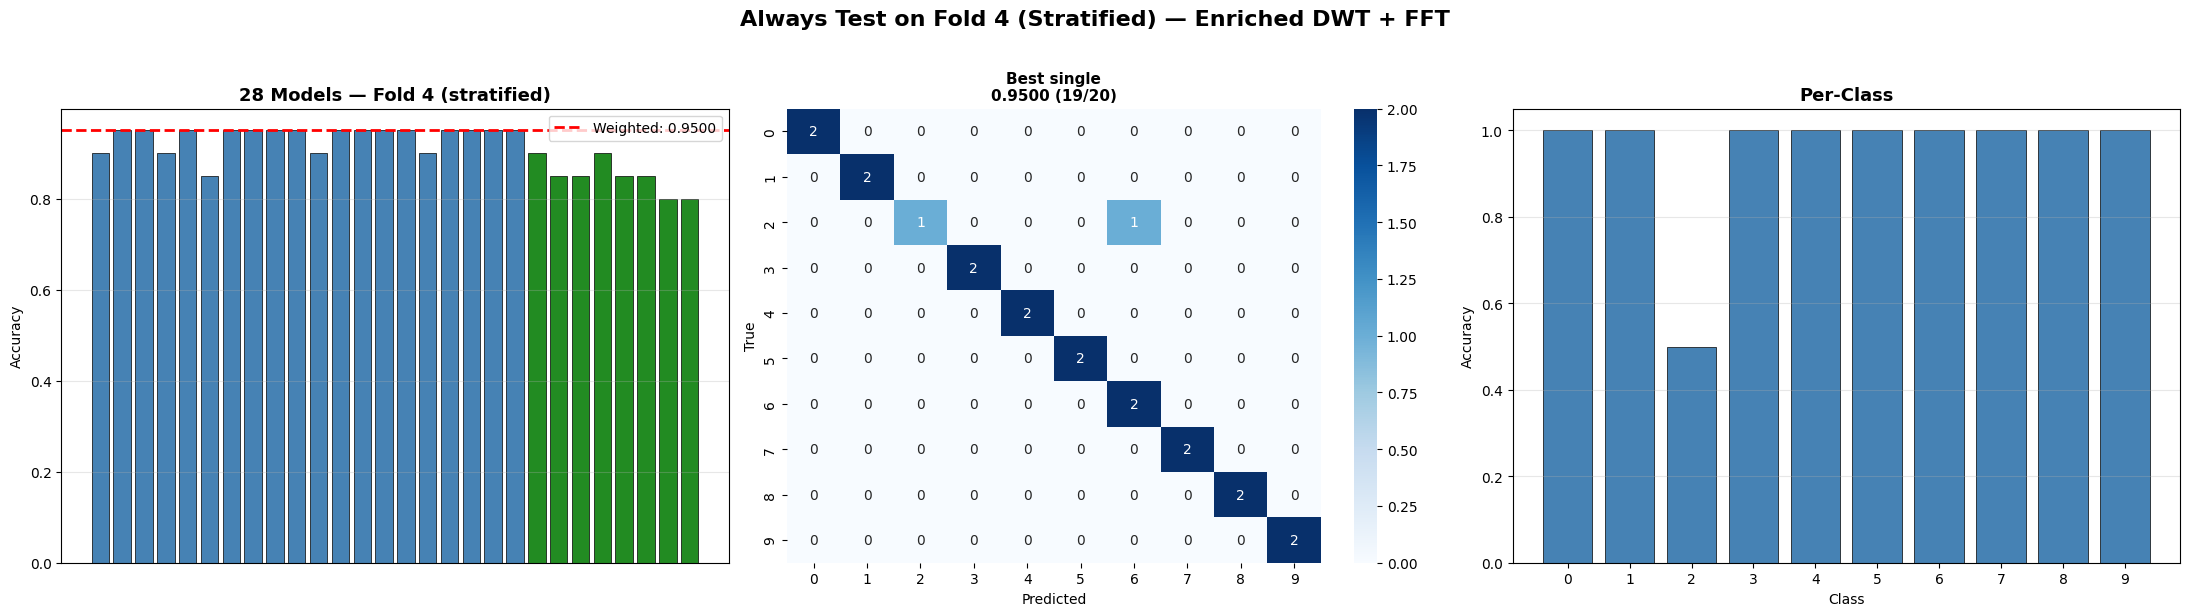


DONE


In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from scipy.fft import fft
from scipy.stats import skew, kurtosis
import pywt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    import lightgbm as lgb
    HAS_LGB = True
except:
    HAS_LGB = False

try:
    import catboost as cb
    HAS_CB = True
except:
    HAS_CB = False

# ============================================================
# LOAD
# ============================================================
df_train = pd.read_csv("train.csv", header=None)
y_full = df_train.iloc[:, 0].values.astype(int)
X_full = df_train.iloc[:, 1:].values.astype(float)

classes = sorted(np.unique(y_full))
print(f"Data: {X_full.shape}  Classes: {classes}")

# ============================================================
# STRATIFIED 5-FOLD → ALWAYS TEST ON FOLD 4 (index 3)
# ============================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(X_full, y_full))

train_idx, test_idx = folds[3]  # 4th fold (0-indexed = 3)

X_train = X_full[train_idx]
y_train = y_full[train_idx]
X_test = X_full[test_idx]
y_test = y_full[test_idx]

print(f"\nFOLD 4 (stratified) = always test")
print(f"Train: {len(y_train)} samples | Test: {len(y_test)} samples")
print(f"Train classes: {np.unique(y_train)} ({dict(zip(*np.unique(y_train, return_counts=True)))})")
print(f"Test classes:  {np.unique(y_test)} ({dict(zip(*np.unique(y_test, return_counts=True)))})")

# ============================================================
# DELTAS
# ============================================================
def seasonal_diff(X, s):
    return np.array([row[s:] - row[:-s] for row in X])

def first_diff(X):
    return np.array([np.diff(row) for row in X])

# ============================================================
# ENRICHED DWT + FFT
# ============================================================
def dwt_enriched(series, wavelet='db4', level=4):
    n = len(series)
    next_pow2 = 1
    while next_pow2 < n:
        next_pow2 *= 2
    padded = np.zeros(next_pow2)
    padded[:n] = series
    coeffs = pywt.wavedec(padded, wavelet, level=level)
    features = []
    energies = []
    for c in coeffs:
        e = np.sum(c ** 2)
        energies.append(e)
        features.append(np.mean(c))
        features.append(np.std(c))
        features.append(np.var(c))
        features.append(np.min(c))
        features.append(np.max(c))
        features.append(np.median(c))
        features.append(e)
        features.append(skew(c))
        features.append(kurtosis(c))
        features.append(np.percentile(c, 25))
        features.append(np.percentile(c, 75))
        zc = np.sum(np.diff(np.sign(c)) != 0)
        features.append(zc / len(c))
    total_energy = sum(energies)
    for e in energies:
        features.append(e / (total_energy + 1e-10))
    return features

def fft_features(series):
    n = len(series)
    mags = np.abs(fft(series)[:n // 2])
    freqs = np.fft.fftfreq(n, d=1)[:n // 2]
    features = []
    if len(mags) > 5:
        m = mags[1:]
        f = freqs[1:]
        idx = np.argsort(m)[::-1][:5]
        for i in idx:
            features.append(f[i])
            features.append(m[i])
    else:
        features.extend([0.0, 0.0] * 5)
    features.append(np.mean(series))
    features.append(np.var(series))
    features.append(np.std(series))
    features.append(np.min(series))
    features.append(np.max(series))
    features.append(np.median(series))
    return features

def build_features(X):
    d1 = first_diff(X)
    ds2 = seasonal_diff(X, 2)
    ds4 = seasonal_diff(X, 4)
    ds6 = seasonal_diff(X, 6)
    d1_s2 = seasonal_diff(d1, 2)
    d1_s4 = seasonal_diff(d1, 4)
    d1_s6 = seasonal_diff(d1, 7)
    # Fix: d1_s6 needs correct param
    d1_s6 = seasonal_diff(d1, 6)
    all_series = [X, ds2, ds4, ds6, d1_s2, d1_s4, d1_s6]
    dwt_parts = []
    wavelets = ['db4', 'db6', 'db8', 'sym5', 'coif3', 'bior3.5']
    for s in all_series:
        for w in wavelets:
            dwt_parts.append(np.array([dwt_enriched(r, wavelet=w) for r in s]))
    fft_parts = []
    for s in all_series:
        fft_parts.append(np.array([fft_features(r) for r in s]))
    mega = np.column_stack(dwt_parts + fft_parts)
    return np.nan_to_num(mega, nan=0, posinf=0, neginf=0)

print("\nBuilding features...")
X_tr = build_features(X_train)
X_te = build_features(X_test)
print(f"Features: train={X_tr.shape} test={X_te.shape}")

# ============================================================
# XGBOOST CONFIGS
# ============================================================
XGB_CONFIGS = [
    {"n": 300,  "d": 4, "lr": 0.1,  "s": 42},
    {"n": 500,  "d": 6, "lr": 0.05, "s": 42},
    {"n": 500,  "d": 8, "lr": 0.05, "s": 42},
    {"n": 500,  "d": 6, "lr": 0.05, "s": 7},
    {"n": 500,  "d": 6, "lr": 0.05, "s": 56},
    {"n": 500,  "d": 6, "lr": 0.05, "s": 91},
    {"n": 1000, "d": 4, "lr": 0.03, "s": 42},
    {"n": 1000, "d": 6, "lr": 0.03, "s": 42},
    {"n": 1000, "d": 8, "lr": 0.03, "s": 42},
    {"n": 1000, "d": 6, "lr": 0.01, "s": 42},
    {"n": 1000, "d": 6, "lr": 0.03, "s": 7},
    {"n": 1000, "d": 6, "lr": 0.03, "s": 56},
    {"n": 1000, "d": 6, "lr": 0.03, "s": 91},
    {"n": 2000, "d": 4, "lr": 0.01, "s": 42},
    {"n": 2000, "d": 6, "lr": 0.01, "s": 42},
    {"n": 2000, "d": 6, "lr": 0.01, "s": 7},
    {"n": 2000, "d": 6, "lr": 0.01, "s": 56},
    {"n": 2000, "d": 6, "lr": 0.01, "s": 91},
    {"n": 3000, "d": 4, "lr": 0.01, "s": 42},
    {"n": 5000, "d": 4, "lr": 0.005,"s": 42},
]

LGB_CONFIGS = []
if HAS_LGB:
    LGB_CONFIGS = [
        {"n": 500,  "d": 6, "lr": 0.05, "s": 42},
        {"n": 1000, "d": 6, "lr": 0.03, "s": 42},
        {"n": 1000, "d": 8, "lr": 0.03, "s": 42},
        {"n": 1000, "d": 6, "lr": 0.03, "s": 7},
        {"n": 1000, "d": 6, "lr": 0.03, "s": 56},
        {"n": 2000, "d": 4, "lr": 0.01, "s": 42},
        {"n": 2000, "d": 6, "lr": 0.01, "s": 42},
        {"n": 3000, "d": 4, "lr": 0.005,"s": 42},
    ]

CB_CONFIGS = []
if HAS_CB:
    CB_CONFIGS = [
        {"n": 500,  "d": 6, "lr": 0.05, "s": 42},
        {"n": 1000, "d": 6, "lr": 0.03, "s": 42},
        {"n": 1000, "d": 8, "lr": 0.03, "s": 42},
        {"n": 1000, "d": 6, "lr": 0.03, "s": 7},
        {"n": 2000, "d": 6, "lr": 0.01, "s": 42},
    ]

# ============================================================
# TRAIN ALL
# ============================================================
n_test = len(y_test)
print(f"\n{'='*70}")
print(f"TRAIN ON 80 — TEST ON FOLD 4 ({n_test} samples)")
print(f"{'='*70}")

all_preds = []
all_results = []

# XGBoost
print("\nXGBoost:")
for i, cfg in enumerate(XGB_CONFIGS):
    model = xgb.XGBClassifier(
        n_estimators=cfg["n"], max_depth=cfg["d"],
        learning_rate=cfg["lr"], subsample=0.8, colsample_bytree=0.7,
        random_state=cfg["s"], n_jobs=-1,
        eval_metric='mlogloss', use_label_encoder=False,
    )
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    acc = accuracy_score(y_test, pred)
    all_preds.append(pred)
    all_results.append({"name": f"XGB e={cfg['n']} d={cfg['d']} s={cfg['s']}", "acc": acc})
    correct = int(acc * n_test)
    print(f"  {i+1:2d}. e={cfg['n']:>4d} d={cfg['d']:>2d} lr={cfg['lr']:.3f} "
          f"s={cfg['s']:>3d} → {acc:.4f}  ({correct}/{n_test})")

# LightGBM
if HAS_LGB:
    print("\nLightGBM:")
    for cfg in LGB_CONFIGS:
        model = lgb.LGBMClassifier(
            n_estimators=cfg["n"], max_depth=cfg["d"],
            learning_rate=cfg["lr"], subsample=0.8, colsample_bytree=0.7,
            random_state=cfg["s"], n_jobs=-1, verbose=-1,
        )
        model.fit(X_tr, y_train)
        pred = model.predict(X_te)
        acc = accuracy_score(y_test, pred)
        all_preds.append(pred)
        all_results.append({"name": f"LGB e={cfg['n']} d={cfg['d']} s={cfg['s']}", "acc": acc})
        correct = int(acc * n_test)
        print(f"  e={cfg['n']:>4d} d={cfg['d']} lr={cfg['lr']:.3f} s={cfg['s']} "
              f"→ {acc:.4f}  ({correct}/{n_test})")

# CatBoost
if HAS_CB:
    print("\nCatBoost:")
    for cfg in CB_CONFIGS:
        model = cb.CatBoostClassifier(
            iterations=cfg["n"], depth=cfg["d"],
            learning_rate=cfg["lr"], random_seed=cfg["s"], verbose=0,
        )
        model.fit(X_tr, y_train)
        pred = model.predict(X_te).flatten().astype(int)
        acc = accuracy_score(y_test, pred)
        all_preds.append(pred)
        all_results.append({"name": f"CB e={cfg['n']} d={cfg['d']} s={cfg['s']}", "acc": acc})
        correct = int(acc * n_test)
        print(f"  e={cfg['n']:>4d} d={cfg['d']} lr={cfg['lr']:.3f} s={cfg['s']} "
              f"→ {acc:.4f}  ({correct}/{n_test})")

# ============================================================
# ENSEMBLES
# ============================================================
def majority_vote(preds):
    final = []
    for i in range(n_test):
        votes = [p[i] for p in preds]
        labels, counts = np.unique(votes, return_counts=True)
        final.append(labels[np.argmax(counts)])
    return np.array(final)

def weighted_vote(preds, results):
    final = []
    for i in range(n_test):
        scores = {c: 0.0 for c in classes}
        for p, r in zip(preds, results):
            scores[p[i]] += r['acc']
        final.append(max(scores, key=scores.get))
    return np.array(final)

print(f"\n{'='*70}")
print("ENSEMBLES")
print(f"{'='*70}")

acc_maj = accuracy_score(y_test, majority_vote(all_preds))
acc_wgt = accuracy_score(y_test, weighted_vote(all_preds, all_results))

print(f"\n  Majority (all {len(all_preds)}):  {acc_maj:.4f}  ({int(acc_maj*n_test)}/{n_test})")
print(f"  Weighted (all {len(all_preds)}):  {acc_wgt:.4f}  ({int(acc_wgt*n_test)}/{n_test})")

sorted_idx = np.argsort([r['acc'] for r in all_results])[::-1]
for k in [3, 5, 10, 15]:
    if k > len(all_preds):
        continue
    top_i = sorted_idx[:k]
    top_p = [all_preds[i] for i in top_i]
    top_r = [all_results[i] for i in top_i]
    acc = accuracy_score(y_test, weighted_vote(top_p, top_r))
    print(f"  Weighted top-{k:2d}: {acc:.4f}  ({int(acc*n_test)}/{n_test})")

# ============================================================
# BEST OVERALL
# ============================================================
candidates = {
    "Best single": (all_results[sorted_idx[0]]['acc'], all_preds[sorted_idx[0]]),
    "Majority (all)": (acc_maj, majority_vote(all_preds)),
    "Weighted (all)": (acc_wgt, weighted_vote(all_preds, all_results)),
}
for k in [3, 5, 10, 15]:
    if k > len(all_preds):
        continue
    top_i = sorted_idx[:k]
    top_p = [all_preds[i] for i in top_i]
    top_r = [all_results[i] for i in top_i]
    acc = accuracy_score(y_test, weighted_vote(top_p, top_r))
    candidates[f"Weighted top-{k}"] = (acc, weighted_vote(top_p, top_r))

best_name = max(candidates, key=lambda k: candidates[k][0])
best_acc, best_pred = candidates[best_name]

print(f"\n{'='*70}")
print(f"BEST: {best_name} → {best_acc:.4f}  ({int(best_acc*n_test)}/{n_test})")
print(f"{'='*70}")
print(classification_report(y_test, best_pred, digits=4, zero_division=0))

cm = confusion_matrix(y_test, best_pred, labels=classes)
print("Per-class:")
for c in classes:
    rs = cm.sum(axis=1)[c]
    print(f"  Class {c}: {cm[c,c]}/{rs} = {cm[c,c]/rs:.3f}" if rs > 0
          else f"  Class {c}: N/A")

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

all_accs = [r['acc'] for r in all_results]
colors = []
for r in all_results:
    if r['name'].startswith("XGB"): colors.append('steelblue')
    elif r['name'].startswith("LGB"): colors.append('forestgreen')
    else: colors.append('darkorange')

axes[0].bar(range(len(all_accs)), all_accs, color=colors,
            edgecolor='black', linewidth=0.5)
axes[0].axhline(y=acc_wgt, color='red', linestyle='--', linewidth=2,
                label=f'Weighted: {acc_wgt:.4f}')
axes[0].set_ylabel('Accuracy')
axes[0].set_title(f'{len(all_results)} Models — Fold 4 (stratified)',
                  fontsize=13, fontweight='bold')
axes[0].set_xticks([])
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=classes, yticklabels=classes)
axes[1].set_title(f'{best_name}\n{best_acc:.4f} ({int(best_acc*n_test)}/{n_test})',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

per_class = []
for c in classes:
    rs = cm.sum(axis=1)[c]
    per_class.append(cm[c,c] / rs if rs > 0 else 0)
axes[2].bar(classes, per_class, color='steelblue', edgecolor='black', linewidth=0.5)
axes[2].set_xlabel('Class')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Per-Class', fontsize=13, fontweight='bold')
axes[2].set_xticks(classes)
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Always Test on Fold 4 (Stratified) — Enriched DWT + FFT',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fold4_stratified_boosting.png', dpi=200, bbox_inches='tight')
plt.show()

print("\nDONE")


In [ ]:
import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.fft import fft
from scipy.stats import skew, kurtosis
import pywt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# LOAD
# ============================================================
df_train = pd.read_csv("train.csv", header=None)
y_train = df_train.iloc[:, 0].values.astype(int)
X_train = df_train.iloc[:, 1:].values.astype(float)

df_test = pd.read_csv("test.csv")
test_ids = df_test.iloc[:, 0].values  # Save Id column
X_test = df_test.iloc[:, 1:].values.astype(float)

n_feat = min(X_train.shape[1], X_test.shape[1])
X_train = X_train[:, :n_feat]
X_test = X_test[:, :n_feat]

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Using {n_feat} features")

# ============================================================
# DELTAS
# ============================================================
def seasonal_diff(X, s):
    return np.array([row[s:] - row[:-s] for row in X])

def first_diff(X):
    return np.array([np.diff(row) for row in X])

# ============================================================
# DWT + FFT FEATURES
# ============================================================
def dwt_enriched(series, wavelet='db4', level=4):
    n = len(series)
    next_pow2 = 1
    while next_pow2 < n:
        next_pow2 *= 2
    padded = np.zeros(next_pow2)
    padded[:n] = series
    coeffs = pywt.wavedec(padded, wavelet, level=level)
    features = []
    energies = []
    for c in coeffs:
        e = np.sum(c ** 2)
        energies.append(e)
        features.append(np.mean(c))
        features.append(np.std(c))
        features.append(np.var(c))
        features.append(np.min(c))
        features.append(np.max(c))
        features.append(np.median(c))
        features.append(e)
        features.append(skew(c))
        features.append(kurtosis(c))
        features.append(np.percentile(c, 25))
        features.append(np.percentile(c, 75))
        zc = np.sum(np.diff(np.sign(c)) != 0)
        features.append(zc / len(c))
    total_energy = sum(energies)
    for e in energies:
        features.append(e / (total_energy + 1e-10))
    return features

def fft_features(series):
    n = len(series)
    mags = np.abs(fft(series)[:n // 2])
    freqs = np.fft.fftfreq(n, d=1)[:n // 2]
    features = []
    if len(mags) > 5:
        m = mags[1:]
        f = freqs[1:]
        idx = np.argsort(m)[::-1][:5]
        for i in idx:
            features.append(f[i])
            features.append(m[i])
    else:
        features.extend([0.0, 0.0] * 5)
    features.append(np.mean(series))
    features.append(np.var(series))
    features.append(np.std(series))
    features.append(np.min(series))
    features.append(np.max(series))
    features.append(np.median(series))
    return features

def build_features(X):
    d1 = first_diff(X)
    ds2 = seasonal_diff(X, 2)
    ds4 = seasonal_diff(X, 4)
    ds6 = seasonal_diff(X, 6)
    d1_s2 = seasonal_diff(d1, 2)
    d1_s4 = seasonal_diff(d1, 4)
    d1_s6 = seasonal_diff(d1, 6)
    all_series = [X, ds2, ds4, ds6, d1_s2, d1_s4, d1_s6]
    dwt_parts = []
    wavelets = ['db4', 'db6', 'db8', 'sym5', 'coif3', 'bior3.5']
    for s in all_series:
        for w in wavelets:
            dwt_parts.append(np.array([dwt_enriched(r, wavelet=w) for r in s]))
    fft_parts = []
    for s in all_series:
        fft_parts.append(np.array([fft_features(r) for r in s]))
    mega = np.column_stack(dwt_parts + fft_parts)
    return np.nan_to_num(mega, nan=0, posinf=0, neginf=0)

print("\nBuilding features...")
X_tr = build_features(X_train)
X_te = build_features(X_test)
print(f"Features: train={X_tr.shape} test={X_te.shape}")

# ============================================================
# TRAIN BEST MODEL — seed=91 config
# ============================================================
print("\nTraining XGBoost (e=2000, d=6, lr=0.01, seed=91)...")

model = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=6,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.7,
    random_state=91,
    n_jobs=-1,
    eval_metric='mlogloss',
    use_label_encoder=False,
)
model.fit(X_tr, y_train)

print("Predicting test.csv...")
pred = model.predict(X_te)

# ============================================================
# SAVE CSV
# ============================================================
output = pd.DataFrame({
    'Id': test_ids,
    'Predicted': pred,
})
output.to_csv('predictions.csv', index=False)

print(f"\nSaved {len(pred)} predictions to predictions.csv")
print(f"\nPredicted class distribution:")
labels, counts = np.unique(pred, return_counts=True)
for l, c in zip(labels, counts):
    print(f"  Class {l}: {c}")

print(f"\nFirst 10 predictions:")
print(output.head(10).to_string(index=False))

print("\nDONE")
